# EDA_Lab(1)

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import requests

In [14]:
df = sns.load_dataset("titanic")

In [15]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Finding Null Values

In [17]:
df.isnull().sum() # Count mising values

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [18]:
df.isnull().sum() / len(df) * 100 # Percentage of missing valuesin each column

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

<Axes: >

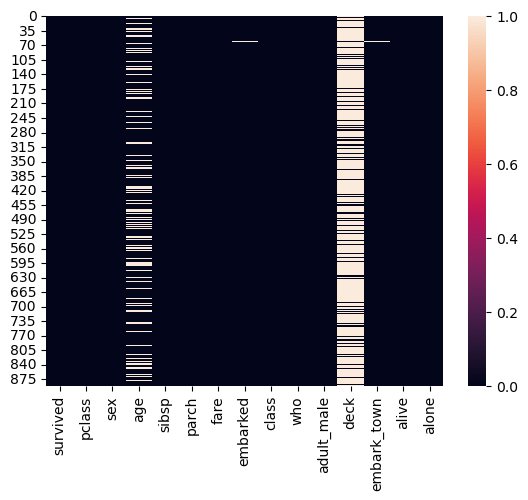

In [19]:
sns.heatmap(df.isnull()) # Missing values using graphs

### Ways to clean data
- 1: If a column has so many null values, remove that entire column from yuor data
- 2: If a row has null value(s) then remove the entire row
- 3: Replace with Mean, Median and Mode (depending on the situation)
- 4: If a column is not numeric then replace by mode

# Missing Value Imputation: Complete Guide

---

## 1. What Are Missing Values?

Missing values are data points that are not recorded.

**Example:**

| Name | Age | Salary |
|------|-----|--------|
| Ali  | 25  | 50k    |
| Sara | NaN | 60k    |
| John | 30  | NaN    |

- `NaN` = Not a Number (missing value)
- Models **cannot handle missing values directly**, so we must fix them

---

## 2. Why Values Are Missing (Critical)

Before filling missing values, understand the reason:

---

### 2.1 MCAR (Missing Completely At Random)
- Missing randomly, no pattern
- Example: Someone forgot to fill a form
- Safe to use simple methods

---

### 2.2 MAR (Missing At Random)
- Missing depends on other columns
- Example: Salary missing mostly for young people
- Use smarter methods (KNN, regression)

---

### 2.3 MNAR (Missing Not At Random)
- Missing depends on itself
- Example: Low-income people hide salary
- Hard case — must be handled carefully

---

## 3. Basic Imputation Methods

---

### 3.1 Mean Imputation

Replace missing values with average.

```python
df['Age'].fillna(df['Age'].mean(), inplace=True)
```

**Use when:**
- Data is normally distributed
- Missing percentage is small

**Problems:**
- Reduces variance
- Affected by outliers

---

### 3.2 Median Imputation (Best Default)

Replace with middle value.

```python
df['Age'].fillna(df['Age'].median(), inplace=True)
```

**Use when:**
- Data is skewed (very common)
- Safer than mean

---

### 3.3 Mode Imputation

For categorical data.

```python
df['City'].fillna(df['City'].mode()[0], inplace=True)
```

**Use when:**
- Data is text or categorical

---

### 3.4 Constant Value Imputation

```python
df['City'].fillna("Unknown", inplace=True)
df['Age'].fillna(0, inplace=True)
```

**Use when:**
- Missing itself has meaning

---

### 3.5 Forward Fill / Backward Fill (Time Series)

```python
df.fillna(method='ffill')
df.fillna(method='bfill')
```

**Use when:**
- Time-based or sequential data

---

## 4. Advanced Imputation Methods

---

### 4.1 KNN Imputation

Uses nearest neighbors to estimate values.

```python
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
df_imputed = imputer.fit_transform(df)
```

**Idea:**
- Find similar rows
- Use their values to fill missing data

**Use when:**
- Features are correlated

**Problems:**
- Slow for large datasets
- Needs scaling

---

### 4.2 Regression Imputation

Predict missing values using other features.

**Steps:**
1. Select rows without missing values
2. Train a model
3. Predict missing values

**Use when:**
- Strong relationships between variables

**Problems:**
- Can overfit
- Underestimates variability

---

### 4.3 Iterative Imputer (MICE)

```python
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()
df_imputed = imputer.fit_transform(df)
```

**Idea:**
- Predict missing values multiple times
- Improves accuracy each iteration

**Use when:**
- Complex datasets
- High accuracy needed

**Problems:**
- Computationally expensive

---

## 5. Dropping Data

```python
df.dropna()
```

**Use when:**
- Very few missing values

```python
df.drop(columns=['column_name'])
```

**Use when:**
- Column has more than 50% missing values

---

## 6. Missing Indicator (Pro Trick)

```python
df['Age_missing'] = df['Age'].isnull().astype(int)
```

**Why use it?**
- Model learns that "missing" itself is important information

---

## 7. When To Use What — Decision Guide

| Situation | Method |
|---|---|
| Less than 5% missing | Median |
| Skewed data | Median |
| Normal data | Mean |
| Categorical | Mode / "Unknown" |
| Time series | Forward Fill |
| Correlated features | KNN / Regression |
| Complex dataset | Iterative Imputer |
| More than 50% missing | Drop column |
| Missing has meaning | Add indicator |

---

## 8. Common Mistakes

**Wrong Way (Data Leakage):**

```python
df.fillna(df.mean())
train_test_split(df)
```

**Correct Way:**

```python
train, test = train_test_split(df)
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(train['Age'].median(), inplace=True)
```

> Always fit on train, apply on test.

---

## 9. Real-World Strategy

1. Start simple: Median / Mode
2. Add: Missing indicator
3. Try advanced: KNN / Iterative
4. Compare model performance

---

## 10. Pro Tips

- Median outperforms mean in most real datasets
- Tree-based models (XGBoost, LightGBM) handle missing values natively
- Always check missing patterns before imputing
- Never blindly apply complex methods

---

## Final Insight

Handling missing values is not just filling numbers. It is about preserving the true pattern of data.

- Bad imputation = bad model
- Good imputation = strong model

In [20]:
df.shape

(891, 15)

In [21]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
df["sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [23]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [24]:
df["embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [25]:
df["embarked"].nunique()

3

In [26]:
df["class"].unique()

['Third', 'First', 'Second']
Categories (3, str): ['First', 'Second', 'Third']

In [27]:
df["class"].nunique()

3

In [28]:
df["who"].unique()

<StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str

In [29]:
df["who"].nunique()

3

In [30]:
df["deck"].unique()

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [31]:
df["deck"].nunique()

7

In [32]:
df["embark_town"].unique()

<StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str

In [33]:
df["embark_town"].nunique()

3

In [34]:
df["alive"].unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: str

In [35]:
df["alive"].nunique()

2

In [36]:
df["alone"].unique()

array([False,  True])

In [37]:
df["alone"].nunique()

2

## Find from which town how many people embarked

In [38]:
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

### How to calculate the mean fare of both male and female separately?

In [39]:
df.groupby('sex')['fare'].mean()

sex
female    44.479818
male      25.523893
Name: fare, dtype: float64

In [40]:
df.groupby('class')['fare'].mean()

class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64

In [41]:
df.groupby('survived')['fare'].mean()

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

In [42]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### Group by two columns

In [12]:
df.groupby(["survived", "sex", "class", "who"])["fare"].mean()

survived  sex     class   who  
0         female  First   child    151.550000
                          woman     90.131250
                  Second  woman     18.250000
                  Third   child     23.542264
                          woman     18.863293
          male    First   man       62.894910
                  Second  man       19.488965
                  Third   child     33.073905
                          man       10.793369
1         female  First   child    165.668750
                          woman    104.636798
                  Second  child     29.240000
                          woman     21.130487
                  Third   child     15.070056
                          woman     11.720089
          male    First   child    117.802767
                          man       71.554074
                  Second  child     27.306022
                          man       14.107812
                  Third   child     16.406022
                          man       15.383987
Na

In [44]:
df.groupby(["survived", "sex", "class", "who"]).size()

survived  sex     class   who  
0         female  First   child      1
                          woman      2
                  Second  woman      6
                  Third   child     14
                          woman     58
          male    First   man       77
                  Second  man       91
                  Third   child     19
                          man      281
1         female  First   child      2
                          woman     89
                  Second  child     10
                          woman     60
                  Third   child     16
                          woman     56
          male    First   child      3
                          man       42
                  Second  child      9
                          man        8
                  Third   child      9
                          man       38
dtype: int64

### Correlation Matrix

In [46]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [51]:
correlation_df = df[["fare", "age", "sibsp", "parch", "pclass"]].corr()

<Axes: >

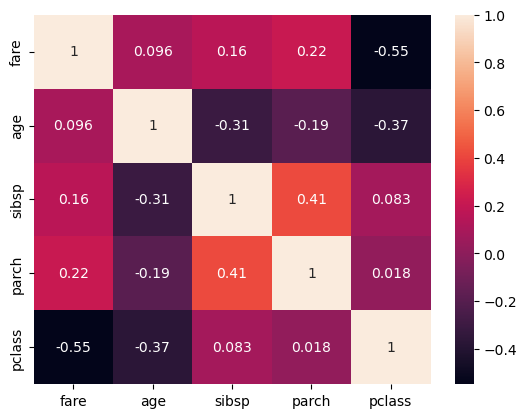

In [54]:
sns.heatmap(correlation_df, annot=True)

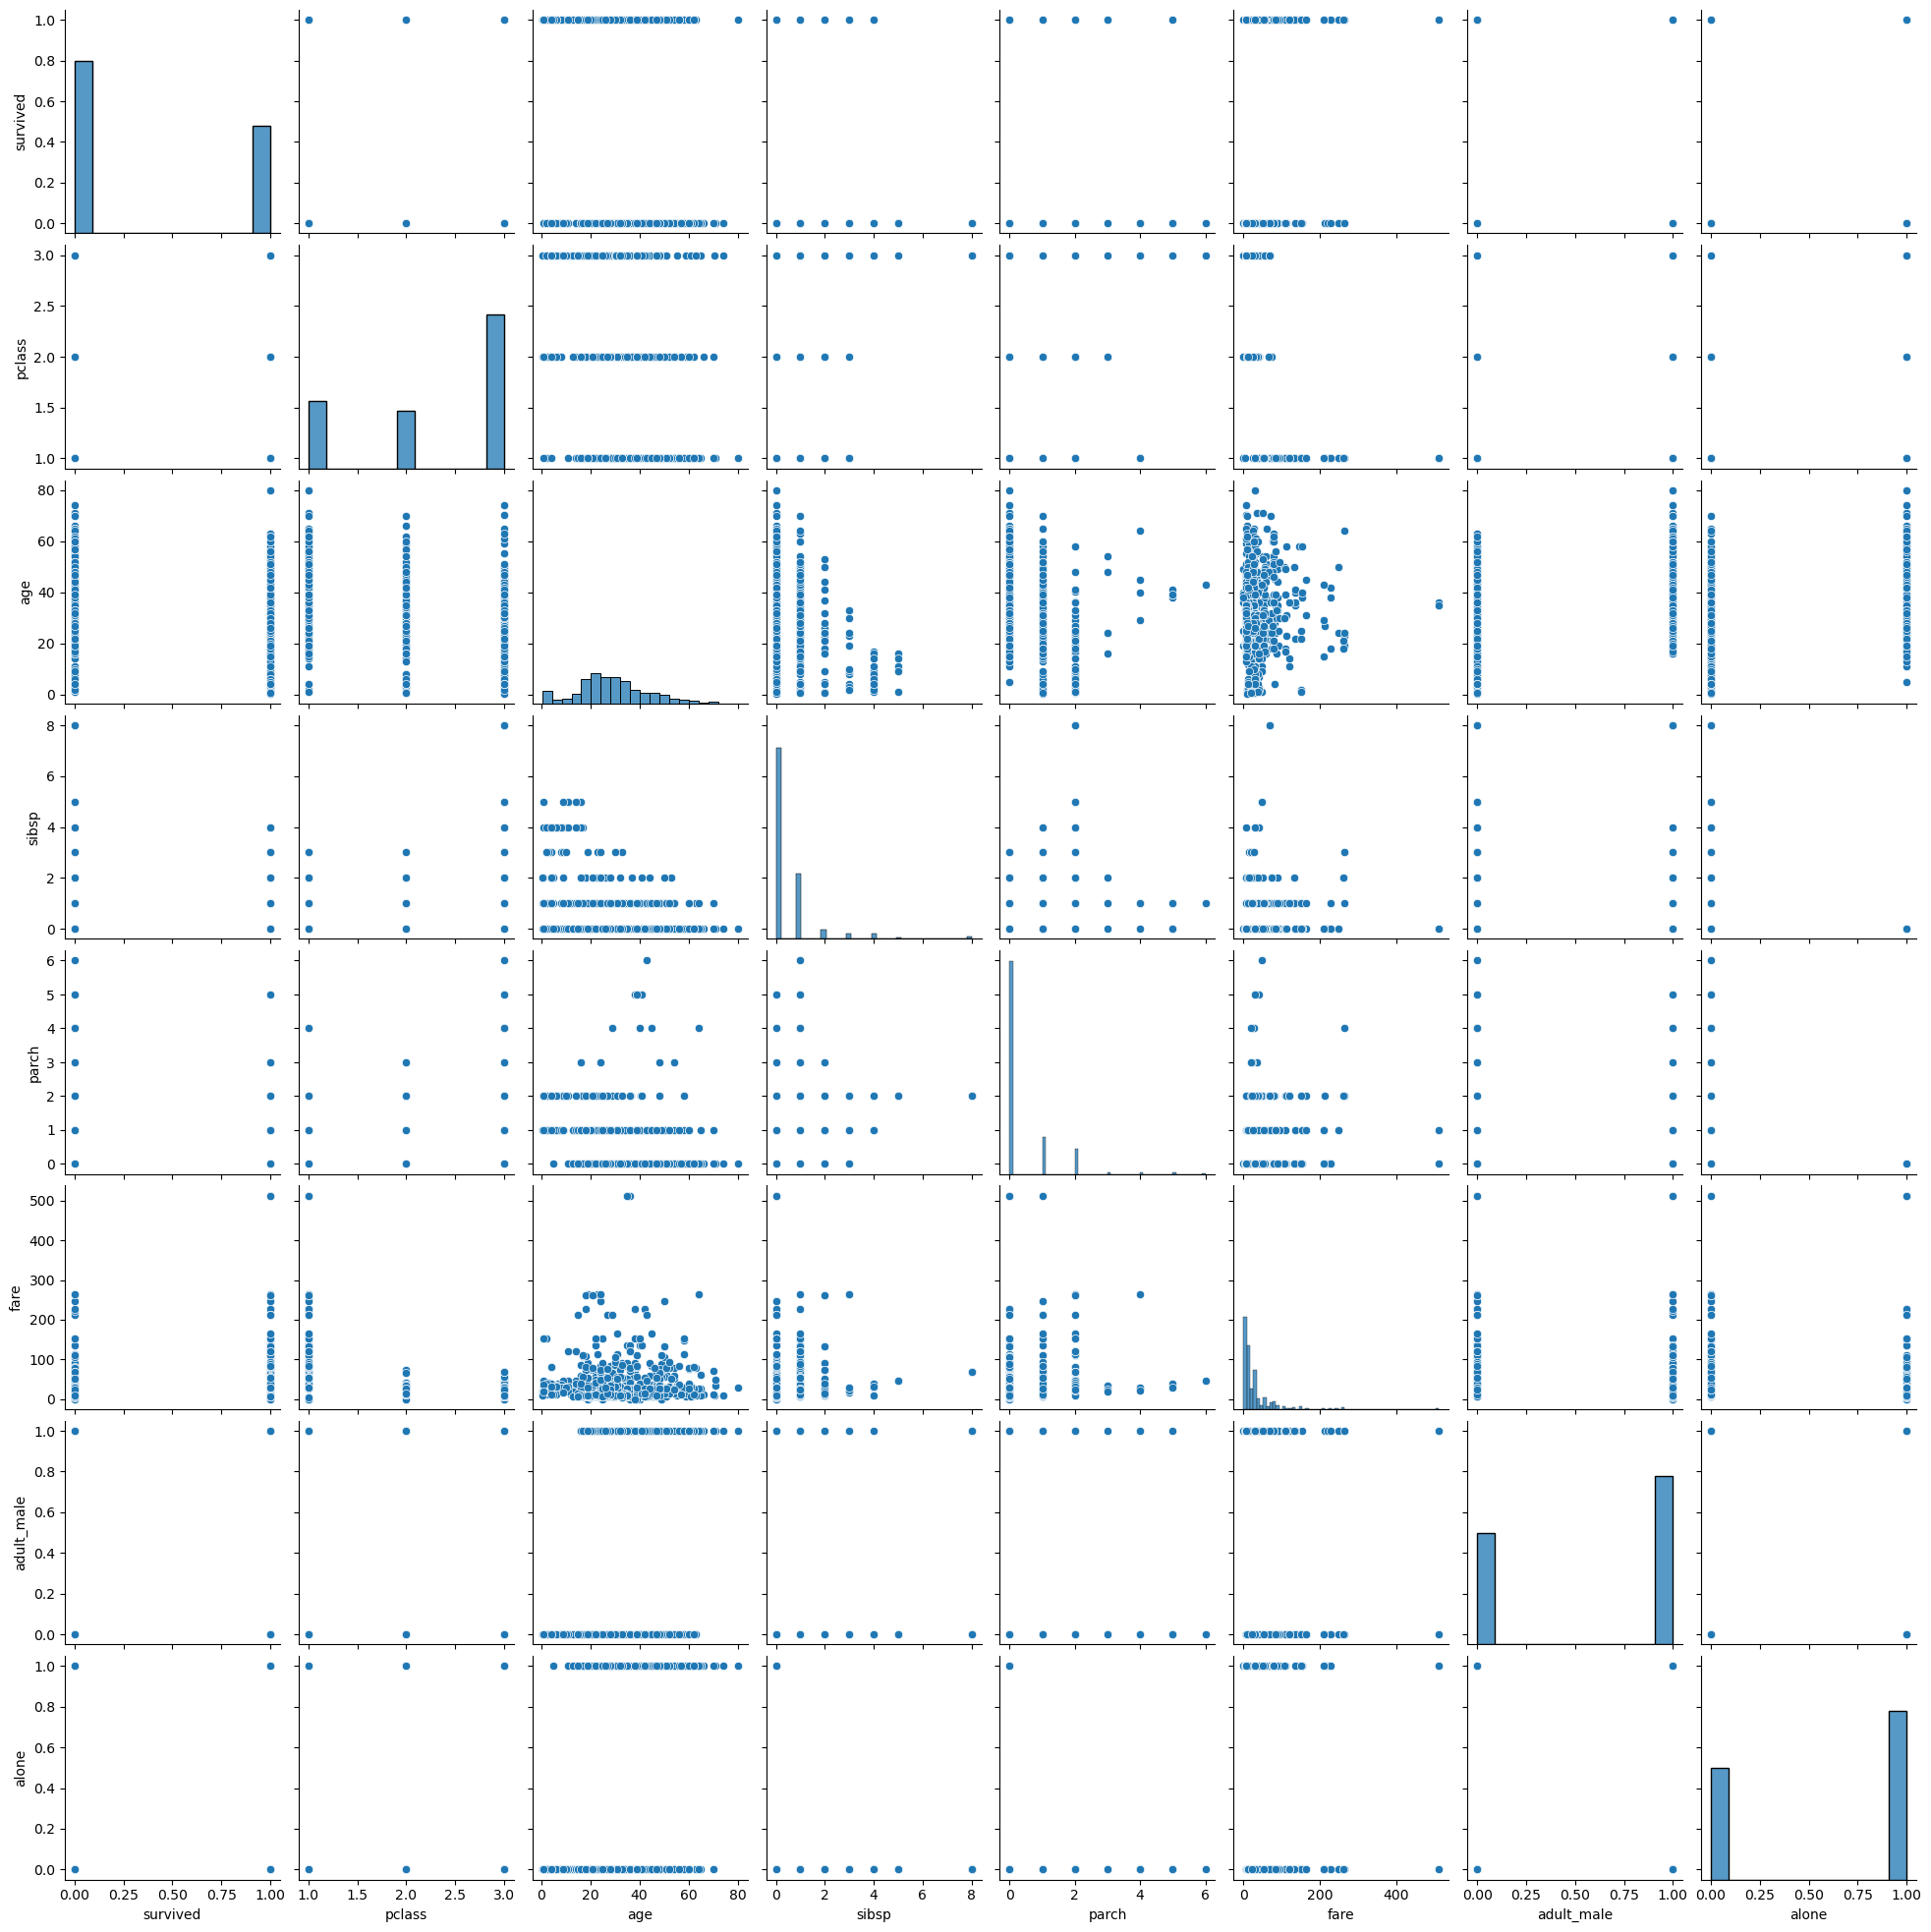

In [55]:
sns.pairplot(df)